# Building Models for Job Posting

**Research question.** Predict the standardized O*NET occupation category (`onet_id`) of a job advertisement from its `requirements_text`.

**Pipeline.** `requirements_text` → TF-IDF vector → ML model → predicted O*NET job title.

**Models compared:** Majority baseline, Logistic Regression, Random Forest, Simple Neural Network (MLP).

**Evaluation:** Accuracy, Precision, Recall, Macro F1, Weighted F1, Confusion matrix.

**Dataset:** [OSF project pfhx3](https://osf.io/pfhx3/overview) — 990 real-world job advertisements from Fortune 500 companies, matched to 32 O*NET occupation categories.

## Setup

Install and import the libraries used throughout the notebook.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)
print("Setup complete.")

Setup complete.


## Step 1 — Exploratory Data Analysis

### Load the dataset

The OSF project `pfhx3` provides an Excel file with two sheets:
- **Data_Master** — 990 job ads with raw text fields.
- **ONET_Job_Titles** — the 32 standardized O*NET job titles, joinable on `onet_id`.

The cell below tries to download the file directly from OSF. If automatic download fails (e.g. file id changes), use the second cell to upload the file manually.

In [ ]:
# Option A: download directly from OSF.
# The OSF project pfhx3 hosts a single Excel file. We resolve the file via
# the public OSF API and download it.
import os, requests

OSF_PROJECT = "pfhx3"
LOCAL_XLSX = "job_ads.xlsx"

def download_from_osf(project_id: str, dest: str) -> str:
    api = f"https://api.osf.io/v2/nodes/{project_id}/files/osfstorage/"
    r = requests.get(api, timeout=30)
    r.raise_for_status()
    files = r.json()["data"]
    # Pick the first .xlsx file in the project storage.
    xlsx = next(f for f in files if f["attributes"]["name"].lower().endswith(".xlsx"))
    download_url = xlsx["links"]["download"]
    print("Downloading:", xlsx["attributes"]["name"])
    with requests.get(download_url, stream=True, timeout=60) as resp:
        resp.raise_for_status()
        with open(dest, "wb") as fh:
            for chunk in resp.iter_content(chunk_size=8192):
                fh.write(chunk)
    return dest

try:
    download_from_osf(OSF_PROJECT, LOCAL_XLSX)
    print("Saved to", LOCAL_XLSX)
except Exception as e:
    print("Automatic download failed:", e)
    print("Run the next cell to upload the file manually.")

Downloading: JobAdsData2022_OSF.xlsx
Saved to job_ads.xlsx


In [ ]:
# Option B (fallback): manual upload via the Colab file picker.
# Run only if Option A failed.
if not os.path.exists(LOCAL_XLSX):
    from google.colab import files
    uploaded = files.upload()
    LOCAL_XLSX = next(iter(uploaded))
    print("Uploaded:", LOCAL_XLSX)

In [ ]:
# Inspect the sheets in the workbook.
xls = pd.ExcelFile(LOCAL_XLSX)
print("Sheets:", xls.sheet_names)

master = pd.read_excel(LOCAL_XLSX, sheet_name="Data Master")
onet   = pd.read_excel(LOCAL_XLSX, sheet_name="ONET Job Titles")

print(f"\nMaster shape: {master.shape}")
print(f"ONET shape:   {onet.shape}")
master.head(3)

Sheets: ['Data Master', 'ONET Job Titles', 'Dictionary']

Master shape: (990, 10)
ONET shape:   (32, 5)


,id,onet_id,job_title,company,job_location,salary,responsibilities_text,requirements_text,preferred_text,company_desc
0,1,43-4131.00,SBA Loan Associate,Bankers Healthcare Group,"Fort Lauderdale, FL",NaN,Assist Business Development Officer with SBA 7(a) loan originations\nAssist Business Development Officer with update...,A successful candidate is a motivated administrative professional who is passionate about working in a growing and g...,NaN,"Are you ready to join a growing team that puts a premium on productivity and has an award-winning culture, centered ..."
1,2,43-4131.00,Credit Analyst,First American Equipment Finance,"Rochester, NY",NaN,"The Credit Analyst is responsible for assisting commercial underwriting including credit and financial analysis, cas...","Bachelor’s degree preferred, or equivalent combination of education, training and experience\nCandidates must posses...",NaN,"First American Equipment Finance, an RBC/City National Company, is a growing, national leader providing equipment le..."
2,3,19-1042.00,"Scientist, Lead Discovery","Accent Therapeutics, Inc.","Lexington, MA",NaN,Design and execution of biochemical assays for multiple novel target classes for use in screening and characterizing...,"BA/BS in Biochemistry, Enzymology or related field plus a minimum of 6 years of industry experience or the equivalen...",NaN,"As a key member of the Lead Discovery team, reporting to the Head of Lead Discovery, the Scientist, Lead Discovery w..."


In [ ]:
onet.head()

,onet_id,title,alt_titles,onet_zone,industry
0,15-1211.00,Computer Systems Analysts,"Applications Analyst, Computer Systems Consultant, IT Analyst, Systems Analyst",4,CompSci
1,15-1252.00,Software Developers,"Application Developer, Network Engineer, Software Engineer",4,CompSci
2,15-1254.00,Web Developers,"Web Architect, Web Designer, Webmaster",3,CompSci
3,15-1232.00,Computer User Support Specialists,"Computer Support, Help Desk, IT Specialist, Support Specialist",3,CompSci
4,25-1081.00,"Education Teachers, Postsecondary","Professor, Adjunct Instructor, Faculty Member, Lecturer",5,Education


### Match the Master file to the O*NET job titles

Join `Data_Master` with `ONET_Job_Titles` on `onet_id` so each ad has a human-readable O*NET label (`onet_title`).

In [ ]:
# Normalise the column name on the ONET sheet so the merge is unambiguous.
onet_renamed = onet.rename(columns={"title": "onet_title"})
df = master.merge(onet_renamed[["onet_id", "onet_title"]], on="onet_id", how="left")

print("Rows after merge:", len(df))
print("Rows with no matched ONET title:", df["onet_title"].isna().sum())
df[["id", "job_title", "onet_id", "onet_title"]].head()

Rows after merge: 990
Rows with no matched ONET title: 0


,id,job_title,onet_id,onet_title
0,1,SBA Loan Associate,43-4131.00,Loan Interviewers and Clerks
1,2,Credit Analyst,43-4131.00,Loan Interviewers and Clerks
2,3,"Scientist, Lead Discovery",19-1042.00,"Medical Scientists, Except Epidemiologists"
3,4,Maintenance Director,49-9071.00,"Maintenance and Repair Workers, General"
4,5,Engineer I,17-2112.00,Industrial Engineers


### Summary statistics

- Number of unique raw `job_title` values
- Number of distinct `onet_id` values (expected: 32)
- Number of raw job titles per O*NET category (vocabulary diversity)
- Number of ads per O*NET category (class imbalance)
- Distribution of `requirements_text` length

In [ ]:
n_raw_titles  = df["job_title"].nunique()
n_onet        = df["onet_id"].nunique()
n_ads         = len(df)

print(f"Number of advertisements:       {n_ads}")
print(f"Number of unique raw job titles: {n_raw_titles}")
print(f"Number of unique O*NET ids:      {n_onet}")

Number of advertisements:       990
Number of unique raw job titles: 825
Number of unique O*NET ids:      32


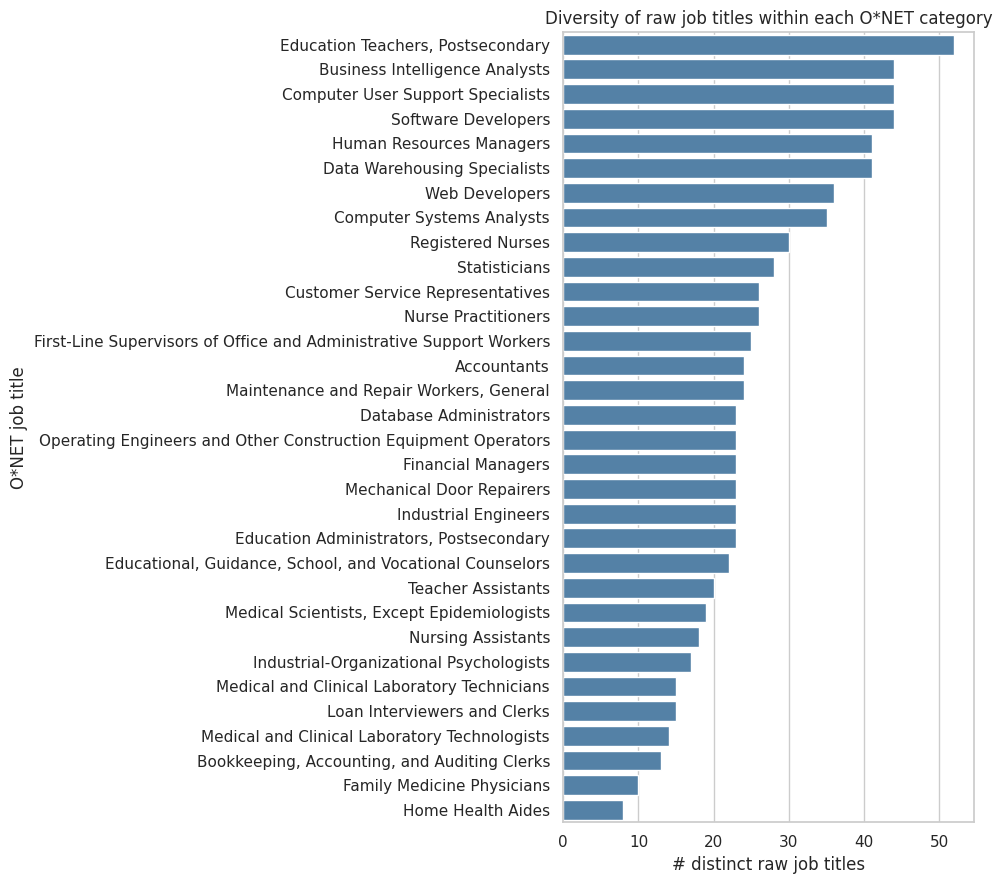

In [ ]:
# Number of distinct raw job titles per O*NET category.
titles_per_onet = (
    df.groupby("onet_title")["job_title"]
      .nunique()
      .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 9))
sns.barplot(x=titles_per_onet.values, y=titles_per_onet.index, ax=ax, color="steelblue")
ax.set_xlabel("# distinct raw job titles")
ax.set_ylabel("O*NET job title")
ax.set_title("Diversity of raw job titles within each O*NET category")
plt.tight_layout()
plt.show()

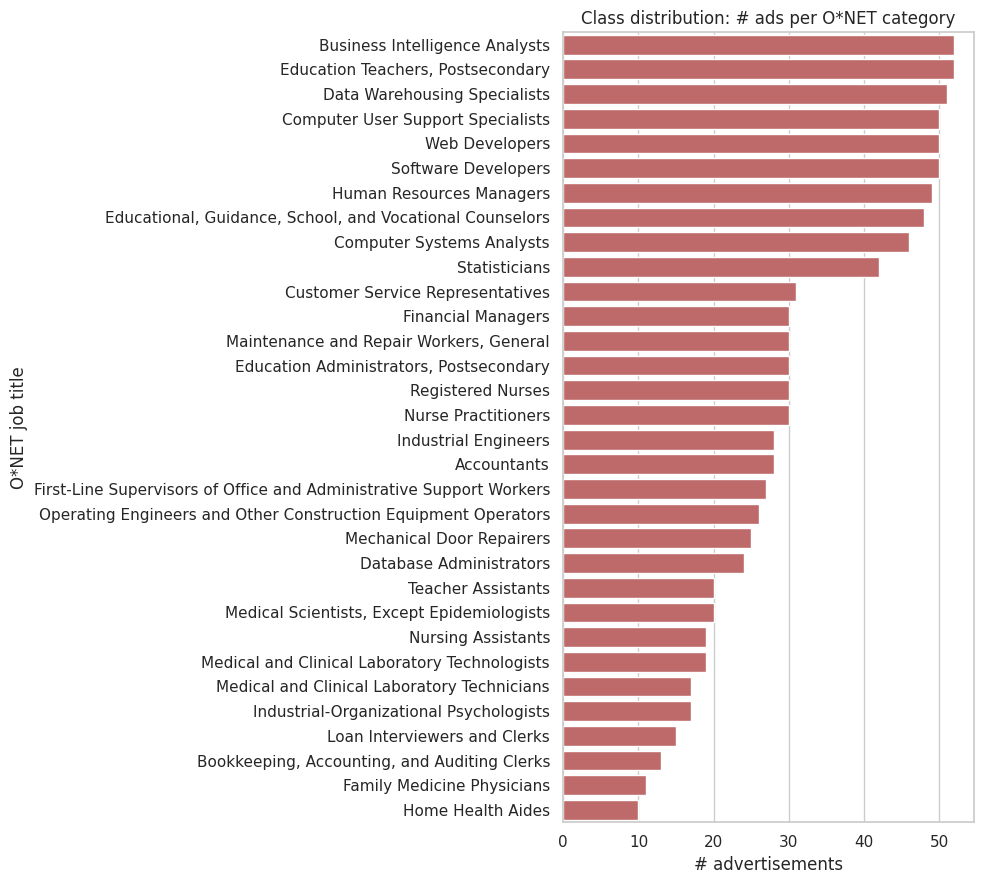

Min class size: 10
Max class size: 52
Mean class size: 30.9


In [ ]:
# Number of ads per O*NET category — class imbalance.
ads_per_onet = (
    df.groupby("onet_title")
      .size()
      .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 9))
sns.barplot(x=ads_per_onet.values, y=ads_per_onet.index, ax=ax, color="indianred")
ax.set_xlabel("# advertisements")
ax.set_ylabel("O*NET job title")
ax.set_title("Class distribution: # ads per O*NET category")
plt.tight_layout()
plt.show()

print(f"Min class size: {ads_per_onet.min()}")
print(f"Max class size: {ads_per_onet.max()}")
print(f"Mean class size: {ads_per_onet.mean():.1f}")

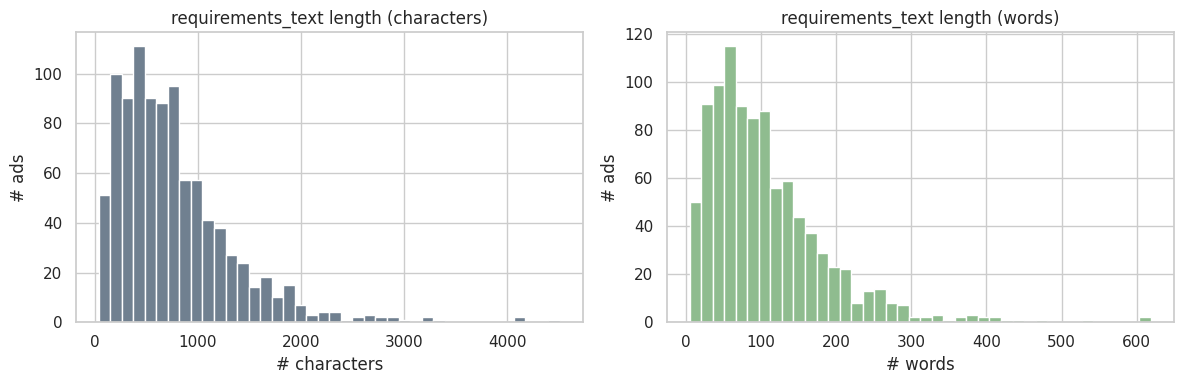

count     961.0
mean      764.7
std       567.5
min        37.0
25%       372.0
50%       639.0
75%      1009.0
max      4511.0
Name: requirements_text, dtype: float64


In [ ]:
# Distribution of requirements_text length (in characters and words).
req = df["requirements_text"].dropna().astype(str)
char_len = req.str.len()
word_len = req.str.split().map(len)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(char_len, bins=40, color="slategray")
axes[0].set_title("requirements_text length (characters)")
axes[0].set_xlabel("# characters"); axes[0].set_ylabel("# ads")

axes[1].hist(word_len, bins=40, color="darkseagreen")
axes[1].set_title("requirements_text length (words)")
axes[1].set_xlabel("# words"); axes[1].set_ylabel("# ads")
plt.tight_layout()
plt.show()

print(char_len.describe().round(1))

### EDA interpretation

The dataset contains 990 real-world job advertisements collected from Fortune 500 company websites. The raw job titles are highly diverse — many hundreds of unique surface-form strings — which makes them a poor target for direct prediction. The dataset authors therefore matched each ad to one of 32 standardized O*NET occupation identifiers, and we predict the **O*NET category**, not the raw job title. The class distribution above shows clear imbalance, so we report both **macro F1** (treats classes equally) and **weighted F1** (weights by support) when comparing models.

## Step 2 — TF-IDF representation

### Step 2.1 Remove rows with missing `requirements_text`

In [ ]:
before = len(df)
df_model = df.dropna(subset=["requirements_text", "onet_id"]).copy()
df_model["requirements_text"] = df_model["requirements_text"].astype(str)
print(f"Dropped {before - len(df_model)} rows with missing requirements_text or onet_id.")
print(f"Remaining: {len(df_model)} ads across {df_model['onet_id'].nunique()} O*NET classes.")

Dropped 29 rows with missing requirements_text or onet_id.
Remaining: 961 ads across 32 O*NET classes.


### Step 2.2 Stratified train / test split

Split **before** fitting the TF-IDF vectoriser to avoid information leakage from the test set into the vocabulary and IDF weights.

In [ ]:
X_text = df_model["requirements_text"].values
y      = df_model["onet_id"].values

# Some O*NET classes may have very few ads — stratify still works as long as
# every class has at least 2 examples. Drop rare classes if necessary.
class_counts = pd.Series(y).value_counts()
keep = class_counts[class_counts >= 2].index
mask = pd.Series(y).isin(keep).values
X_text, y = X_text[mask], y[mask]
print(f"After dropping classes with <2 ads: {len(y)} ads, {pd.Series(y).nunique()} classes.")

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)
print(f"Train: {len(y_train)} ads | Test: {len(y_test)} ads")

After dropping classes with <2 ads: 961 ads, 32 classes.
Train: 768 ads | Test: 193 ads


### Step 2.3 Fit TF-IDF on the training text only

| Setting | Meaning |
| --- | --- |
| `lowercase=True` | Treat *Python* and *python* as the same |
| `stop_words="english"` | Remove common words like *the*, *and*, *of* |
| `ngram_range=(1, 2)` | Use unigrams and bigrams |
| `min_df=2` | Ignore words appearing in only one ad |
| `max_df=0.9` | Ignore words appearing in more than 90% of ads |
| `max_features=5000` | Keep the top 5000 features |

In [ ]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
    max_features=5000,
)

X_train = vectorizer.fit_transform(X_train_text)
X_test  = vectorizer.transform(X_test_text)

print(f"TF-IDF matrix — train: {X_train.shape}, test: {X_test.shape}")
print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")


TF-IDF matrix — train: (768, 5000), test: (193, 5000)
Vocabulary size: 5000


## Step 3 — Models with cross-validated hyperparameter tuning

A shared 5-fold stratified CV is used for tuning each model.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def evaluate(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    return {
        "model":       name,
        "accuracy":    accuracy_score(y_te, y_pred),
        "precision":   precision_score(y_te, y_pred, average="weighted", zero_division=0),
        "recall":      recall_score(y_te, y_pred, average="weighted", zero_division=0),
        "macro_f1":    f1_score(y_te, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_te, y_pred, average="weighted", zero_division=0),
        "y_pred":      y_pred,
    }

results = {}

### 3.1 Majority baseline

Always predicts the most frequent O*NET category in the training data. It does not use the requirements text — included as a minimum benchmark.

In [ ]:
baseline = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)
results["Majority baseline"] = evaluate("Majority baseline", baseline, X_test, y_test)
print(f"Accuracy: {results['Majority baseline']['accuracy']:.3f}")
print(f"Macro F1:    {results['Majority baseline']['macro_f1']:.3f}")
print(f"Weighted F1: {results['Majority baseline']['weighted_f1']:.3f}")

Accuracy: 0.052
Macro F1:    0.003
Weighted F1: 0.005


### 3.2 Logistic Regression

Tune the inverse regularisation strength `C ∈ {0.01, 0.1, 1, 10}` with both L1 and L2 penalties.

| `C` | Regularisation | Meaning |
| --- | --- | --- |
| 0.01 | very strong | model is simple, may underfit |
| 0.1  | strong       | still conservative |
| 1    | medium       | standard starting point |
| 10   | weak         | model is more flexible, may overfit |

In [ ]:
logreg_grid = GridSearchCV(
    LogisticRegression(solver="liblinear", max_iter=2000, random_state=RANDOM_STATE),
    param_grid={
        "C":       [0.01, 0.1, 1, 3, 10, 20, 30, 50, 100],
        "penalty": ["l1", "l2"],
    },
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
)
logreg_grid.fit(X_train, y_train)
print("Best params:", logreg_grid.best_params_)
print(f"Best CV macro F1: {logreg_grid.best_score_:.3f}")

results["Logistic Regression"] = evaluate(
    "Logistic Regression", logreg_grid.best_estimator_, X_test, y_test
)
print(f"Test macro F1:     {results['Logistic Regression']['macro_f1']:.3f}")
print(f"Test weighted F1:  {results['Logistic Regression']['weighted_f1']:.3f}")

Best params: {'C': 100, 'penalty': 'l2'}
Best CV macro F1: 0.514
Test macro F1:     0.496
Test weighted F1:  0.503


### 3.3 Random Forest

Tune the bootstrap sample size, the number of features sampled per split (`max_features`), and `min_samples_leaf`.

- `max_samples`: classical bootstrap of size *n* contains ~63.2% unique observations.
- `max_features="sqrt"` uses √(#features); `0.05`/`0.10` use 5%/10% of features.

In [ ]:
rf_grid = GridSearchCV(
    RandomForestClassifier(
        n_estimators=300,
        bootstrap=True,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    param_grid={
        "max_samples":      [0.632, 0.8, 1.0],
        "max_features":     ["sqrt", 0.05, 0.10],
        "min_samples_leaf": [1, 2, 5],
    },
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
)
# max_samples=1.0 is invalid in some sklearn versions when bootstrap=True;
# fall back gracefully if a single combination errors.
rf_grid.fit(X_train, y_train)
print("Best params:", rf_grid.best_params_)
print(f"Best CV macro F1: {rf_grid.best_score_:.3f}")

results["Random Forest"] = evaluate(
    "Random Forest", rf_grid.best_estimator_, X_test, y_test
)
print(f"Test macro F1:    {results['Random Forest']['macro_f1']:.3f}")
print(f"Test weighted F1: {results['Random Forest']['weighted_f1']:.3f}")

Best params: {'max_features': 0.1, 'max_samples': 0.632, 'min_samples_leaf': 1}
Best CV macro F1: 0.482
Test macro F1:    0.428
Test weighted F1: 0.462


### 3.4 Simple Neural Network (MLP)

Small multi-layer perceptron over the TF-IDF vectors. Tune hidden-layer size and L2 regularisation (`alpha`).

First, simple NLP.

Second, tuned NLP.

Simple NLP without tuning

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode O*NET labels for MLPClassifier
mlp_label_encoder = LabelEncoder()
y_train_mlp = mlp_label_encoder.fit_transform(y_train)

# Untuned MLP over fixed TF-IDF vectors
mlp_untuned = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation="relu",
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=200,
    early_stopping=True,
    random_state=RANDOM_STATE,
)

mlp_untuned.fit(X_train, y_train_mlp)

# Predict numeric labels and decode back to original O*NET ids
y_pred_mlp_untuned_encoded = mlp_untuned.predict(X_test)
y_pred_mlp_untuned = mlp_label_encoder.inverse_transform(y_pred_mlp_untuned_encoded)

results["Neural Network (MLP untuned)"] = {
    "model": "Neural Network (MLP untuned)",
    "accuracy": accuracy_score(y_test, y_pred_mlp_untuned),
    "precision": precision_score(y_test, y_pred_mlp_untuned, average="weighted", zero_division=0),
    "recall": recall_score(y_test, y_pred_mlp_untuned, average="weighted", zero_division=0),
    "macro_f1": f1_score(y_test, y_pred_mlp_untuned, average="macro", zero_division=0),
    "weighted_f1": f1_score(y_test, y_pred_mlp_untuned, average="weighted", zero_division=0),
    "y_pred": y_pred_mlp_untuned,
}

print(f"Test macro F1:    {results['Neural Network (MLP untuned)']['macro_f1']:.3f}")
print(f"Test weighted F1: {results['Neural Network (MLP untuned)']['weighted_f1']:.3f}")

Test macro F1:    0.333
Test weighted F1: 0.402


In [ ]:
Tuned NLP

In [ ]:
# Tune MLP hyperparameters over fixed TF-IDF vectors
mlp_grid = GridSearchCV(
    MLPClassifier(
        max_iter=300,
        early_stopping=True,
        random_state=RANDOM_STATE,
    ),
    param_grid={
        "hidden_layer_sizes": [(100,), (128,), (256,), (128, 64)],
        "activation": ["relu", "tanh"],
        "alpha": [1e-5, 1e-4, 1e-3, 1e-2],
        "learning_rate_init": [1e-4, 1e-3],
    },
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    error_score="raise",
)

mlp_grid.fit(X_train, y_train_mlp)

print("Best params:", mlp_grid.best_params_)
print(f"Best CV macro F1: {mlp_grid.best_score_:.3f}")

# Predict numeric labels and decode back to original O*NET ids
y_pred_mlp_tuned_encoded = mlp_grid.best_estimator_.predict(X_test)
y_pred_mlp_tuned = mlp_label_encoder.inverse_transform(y_pred_mlp_tuned_encoded)

results["Neural Network (MLP tuned)"] = {
    "model": "Neural Network (MLP tuned)",
    "accuracy": accuracy_score(y_test, y_pred_mlp_tuned),
    "precision": precision_score(y_test, y_pred_mlp_tuned, average="weighted", zero_division=0),
    "recall": recall_score(y_test, y_pred_mlp_tuned, average="weighted", zero_division=0),
    "macro_f1": f1_score(y_test, y_pred_mlp_tuned, average="macro", zero_division=0),
    "weighted_f1": f1_score(y_test, y_pred_mlp_tuned, average="weighted", zero_division=0),
    "y_pred": y_pred_mlp_tuned,
}

print(f"Test macro F1:    {results['Neural Network (MLP tuned)']['macro_f1']:.3f}")
print(f"Test weighted F1: {results['Neural Network (MLP tuned)']['weighted_f1']:.3f}")

Best params: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (256,), 'learning_rate_init': 0.001}
Best CV macro F1: 0.449
Test macro F1:    0.436
Test weighted F1: 0.457


Very simply tuned NLP

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode O*NET string labels as numeric labels for MLPClassifier
mlp_label_encoder = LabelEncoder()
y_train_mlp = mlp_label_encoder.fit_transform(y_train)

mlp_grid = GridSearchCV(
    MLPClassifier(
        max_iter=200,
        early_stopping=True,
        random_state=RANDOM_STATE,
    ),
    param_grid={
        "hidden_layer_sizes": [(128,), (256,), (128, 64)],
        "alpha": [1e-4, 1e-3],
    },
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    error_score="raise",
)

mlp_grid.fit(X_train, y_train_mlp)

print("Best params:", mlp_grid.best_params_)
print(f"Best CV macro F1: {mlp_grid.best_score_:.3f}")

# Predict numeric labels, then convert them back to original O*NET IDs
y_pred_mlp_encoded = mlp_grid.best_estimator_.predict(X_test)
y_pred_mlp = mlp_label_encoder.inverse_transform(y_pred_mlp_encoded)

results["Neural Network (MLP)"] = {
    "model": "Neural Network (MLP)",
    "accuracy": accuracy_score(y_test, y_pred_mlp),
    "precision": precision_score(y_test, y_pred_mlp, average="weighted", zero_division=0),
    "recall": recall_score(y_test, y_pred_mlp, average="weighted", zero_division=0),
    "macro_f1": f1_score(y_test, y_pred_mlp, average="macro", zero_division=0),
    "weighted_f1": f1_score(y_test, y_pred_mlp, average="weighted", zero_division=0),
    "y_pred": y_pred_mlp,
}

print(f"Test macro F1:    {results['Neural Network (MLP)']['macro_f1']:.3f}")
print(f"Test weighted F1: {results['Neural Network (MLP)']['weighted_f1']:.3f}")

Best params: {'alpha': 0.001, 'hidden_layer_sizes': (256,)}
Best CV macro F1: 0.438
Test macro F1:    0.362
Test weighted F1: 0.412


Old NLP with bugs -- not used anymore

In [ ]:
mlp_grid = GridSearchCV(
    MLPClassifier(
        max_iter=200,
        early_stopping=True,
        random_state=RANDOM_STATE,
    ),
    param_grid={
        "hidden_layer_sizes": [(128,), (256,), (128, 64)],
        "alpha":              [1e-4, 1e-3],
    },
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
)
mlp_grid.fit(X_train, y_train)
print("Best params:", mlp_grid.best_params_)
print(f"Best CV macro F1: {mlp_grid.best_score_:.3f}")

results["Neural Network (MLP)"] = evaluate(
    "Neural Network (MLP)", mlp_grid.best_estimator_, X_test, y_test
)
print(f"Test macro F1:    {results['Neural Network (MLP)']['macro_f1']:.3f}")
print(f"Test weighted F1: {results['Neural Network (MLP)']['weighted_f1']:.3f}")

ValueError: 
All the 30 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py", line 754, in fit
    return self._fit(X, y, incremental=False)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_p

## Step 4 — Compare models

Side-by-side comparison on the held-out test set.

| Metric | Why it matters |
| --- | --- |
| Accuracy | Overall percentage of correct predictions |
| Precision / Recall | Per-class trade-off, easy to interpret |
| Macro F1 | Performance across **all** O*NET categories equally |
| Weighted F1 | Overall performance accounting for class imbalance |
| Confusion matrix | Shows *which* categories get confused |

In [ ]:
summary = (
    pd.DataFrame([
        {k: v for k, v in r.items() if k != "y_pred"}
        for r in results.values()
    ])
    .set_index("model")
    .round(3)
)
summary

,accuracy,precision,recall,macro_f1,weighted_f1
model,,,,,
Majority baseline,0.052,0.003,0.052,0.003,0.005
Logistic Regression,0.513,0.524,0.513,0.496,0.503
Random Forest,0.482,0.499,0.482,0.428,0.462
Neural Network (MLP),0.440,0.434,0.440,0.362,0.412
Neural Network (MLP untuned),0.435,0.410,0.435,0.333,0.402
Neural Network (MLP tuned),0.477,0.478,0.477,0.436,0.457


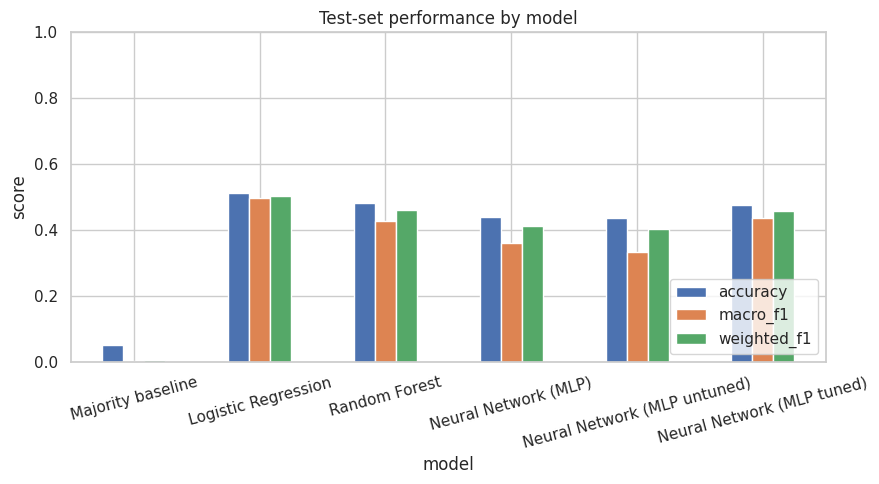

In [ ]:
# Bar plot of the headline metrics for visual comparison.
metrics_to_plot = ["accuracy", "macro_f1", "weighted_f1"]
ax = summary[metrics_to_plot].plot(kind="bar", figsize=(9, 5), rot=15)
ax.set_ylabel("score")
ax.set_ylim(0, 1)
ax.set_title("Test-set performance by model")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

Best model by macro F1: Logistic Regression


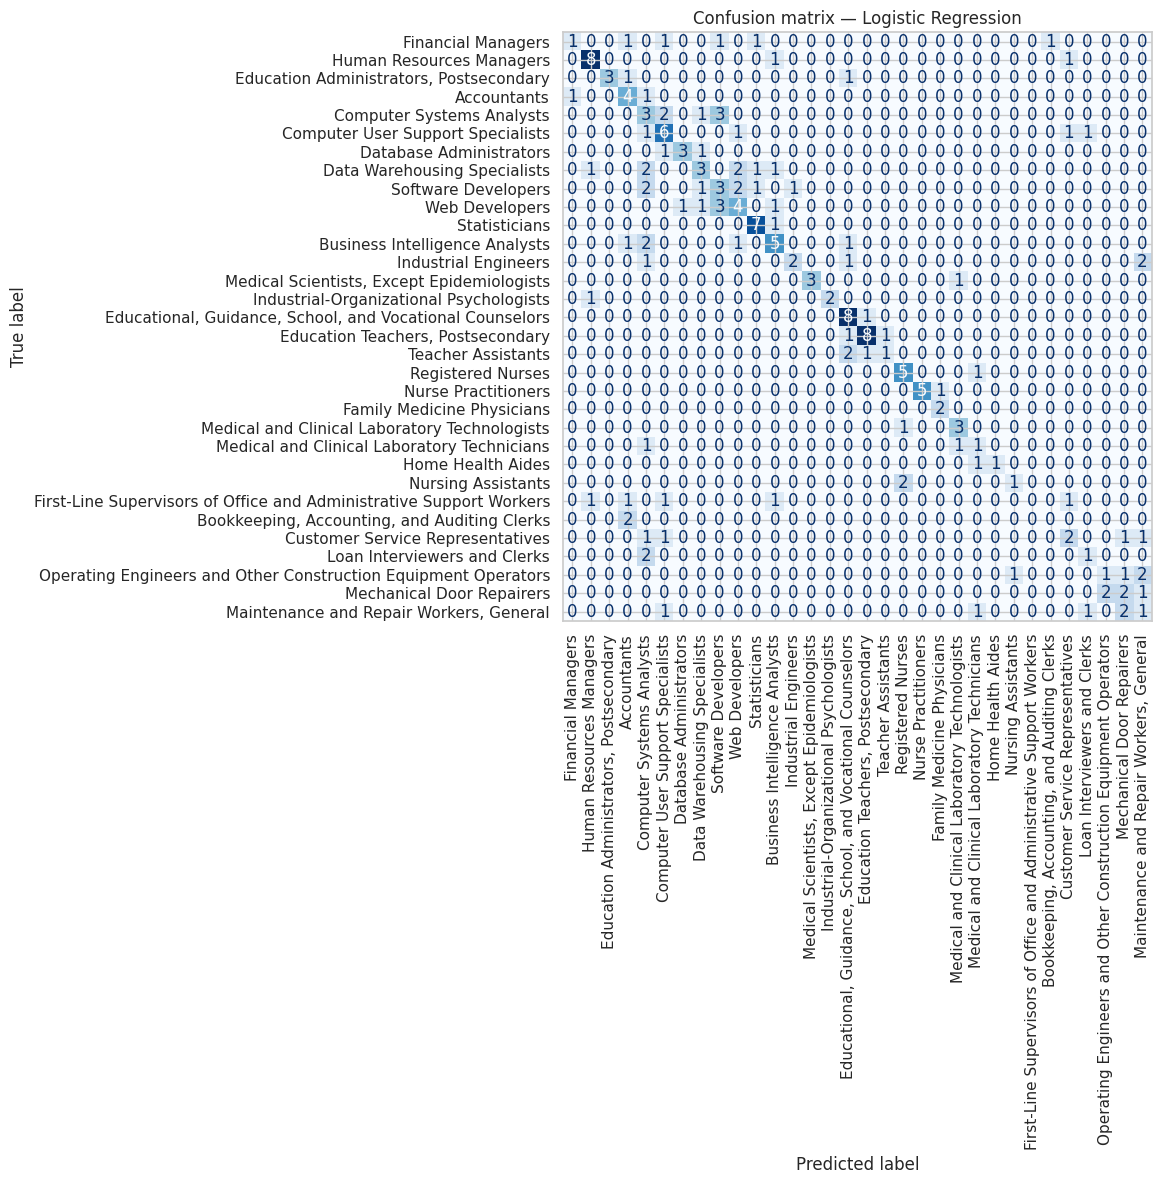

In [ ]:
# Confusion matrix for the best non-baseline model (highest macro F1).
non_baseline = {k: v for k, v in results.items() if k != "Majority baseline"}
best_name = max(non_baseline, key=lambda k: non_baseline[k]["macro_f1"])
print(f"Best model by macro F1: {best_name}")

labels = sorted(np.unique(y_test))
# Map id -> human label for readability.
id_to_title = dict(zip(onet_renamed["onet_id"], onet_renamed["onet_title"]))
display_labels = [id_to_title.get(l, str(l)) for l in labels]

cm = confusion_matrix(y_test, results[best_name]["y_pred"], labels=labels)
fig, ax = plt.subplots(figsize=(12, 12))
disp = ConfusionMatrixDisplay(cm, display_labels=display_labels)
disp.plot(ax=ax, xticks_rotation=90, colorbar=False, cmap="Blues", values_format="d")
ax.set_title(f"Confusion matrix — {best_name}")
plt.tight_layout()
plt.show()

In [ ]:
# Classification report as a sortable DataFrame
report_dict = classification_report(
    y_test,
    results[best_name]["y_pred"],
    labels=labels,
    target_names=display_labels,
    zero_division=0,
    output_dict=True,
)

report_df = (
    pd.DataFrame(report_dict)
      .T
      .reset_index()
      .rename(columns={"index": "O*NET category"})
)

# Keep only real O*NET categories, not summary rows
category_report = report_df[
    ~report_df["O*NET category"].isin(["accuracy", "macro avg", "weighted avg"])
].copy()

# Make sure numeric columns are numeric
for col in ["precision", "recall", "f1-score", "support"]:
    category_report[col] = pd.to_numeric(category_report[col], errors="coerce")

# Top 10 best-predicted categories by class-level F1
top_10_categories = (
    category_report
      .sort_values("f1-score", ascending=False)
      .head(10)
      [["O*NET category", "precision", "recall", "f1-score", "support"]]
      .round(3)
)

# Bottom 10 worst-predicted categories by class-level F1
bottom_10_categories = (
    category_report
      .sort_values("f1-score", ascending=True)
      .head(10)
      [["O*NET category", "precision", "recall", "f1-score", "support"]]
      .round(3)
)

print(f"Best model by macro F1: {best_name}")

print("\nTop 10 O*NET categories by F1-score:")
display(top_10_categories)

print("\nBottom 10 O*NET categories by F1-score:")
display(bottom_10_categories)

top_10_categories.to_csv("top_10_onet_categories.csv", index=False)
bottom_10_categories.to_csv("bottom_10_onet_categories.csv", index=False)



Best model by macro F1: Logistic Regression

Top 10 O*NET categories by F1-score:


,O*NET category,precision,recall,f1-score,support
19,Nurse Practitioners,1.000,0.833,0.909,6.0
13,"Medical Scientists, Except Epidemiologists",1.000,0.750,0.857,4.0
16,"Education Teachers, Postsecondary",0.800,0.800,0.800,10.0
14,Industrial-Organizational Psychologists,1.000,0.667,0.800,3.0
20,Family Medicine Physicians,0.667,1.000,0.800,2.0
10,Statisticians,0.700,0.875,0.778,8.0
1,Human Resources Managers,0.727,0.800,0.762,10.0
2,"Education Administrators, Postsecondary",1.000,0.600,0.750,5.0
18,Registered Nurses,0.625,0.833,0.714,6.0
15,"Educational, Guidance, School, and Vocational Counselors",0.571,0.889,0.696,9.0



Bottom 10 O*NET categories by F1-score:


,O*NET category,precision,recall,f1-score,support
25,First-Line Supervisors of Office and Administrative Support Workers,0.000,0.000,0.000,5.0
26,"Bookkeeping, Accounting, and Auditing Clerks",0.000,0.000,0.000,2.0
31,"Maintenance and Repair Workers, General",0.143,0.167,0.154,6.0
4,Computer Systems Analysts,0.188,0.333,0.240,9.0
29,Operating Engineers and Other Construction Equipment Operators,0.333,0.200,0.250,5.0
0,Financial Managers,0.500,0.167,0.250,6.0
22,Medical and Clinical Laboratory Technicians,0.250,0.333,0.286,3.0
8,Software Developers,0.300,0.300,0.300,10.0
17,Teacher Assistants,0.500,0.250,0.333,4.0
28,Loan Interviewers and Clerks,0.333,0.333,0.333,3.0


In [ ]:
print(classification_report(
    y_test,
    results[best_name]["y_pred"],
    labels=labels,
    target_names=display_labels,
    zero_division=0,
))

                                                                     precision    recall  f1-score   support

                                                 Financial Managers       0.50      0.17      0.25         6
                                           Human Resources Managers       0.73      0.80      0.76        10
                            Education Administrators, Postsecondary       1.00      0.60      0.75         5
                                                        Accountants       0.40      0.67      0.50         6
                                          Computer Systems Analysts       0.19      0.33      0.24         9
                                  Computer User Support Specialists       0.46      0.60      0.52        10
                                            Database Administrators       0.75      0.60      0.67         5
                                       Data Warehousing Specialists       0.43      0.30      0.35        10
                  

## Step 5 — Top words used as predictors

The majority baseline has no feature importance because it ignores the text. For Logistic Regression we read off the top positive coefficients per O*NET class; for Random Forest we use `feature_importances_` (global, not per-class).

In [ ]:
# Top positive Logistic Regression coefficients per class.
logreg = logreg_grid.best_estimator_
feature_names = np.array(vectorizer.get_feature_names_out())

TOP_N = 10
top_words_per_class = {}
for class_idx, class_label in enumerate(logreg.classes_):
    coefs = logreg.coef_[class_idx]
    top_idx = np.argsort(coefs)[-TOP_N:][::-1]
    top_words_per_class[id_to_title.get(class_label, str(class_label))] = list(feature_names[top_idx])

top_words_df = pd.DataFrame(top_words_per_class).T
top_words_df.columns = [f"top_{i+1}" for i in range(TOP_N)]
top_words_df

,top_1,top_2,top_3,top_4,top_5,top_6,top_7,top_8,top_9,top_10
Financial Managers,finance,accounting,financial,experience financial,finance accounting,analysis,degree finance,including years,investment,years accounting
Human Resources Managers,hr,human,employee,human resources,resources,business,payroll,talent,years hr,hr experience
"Education Administrators, Postsecondary",academic,leadership,administrative,progressively responsible,progressively,institution,demonstrated,responsible,staff,strategic
Accountants,accounting,university degree,complete,degree relevant,degree accounting,education bachelor,skills,ability complete,public,cpa
Computer Systems Analysts,security,requirements,degree technical,information,computing,cisco,systems,analytical,sql,informatica
Computer User Support Specialists,ged required,support,windows,technical support,desktop,technical,networking,experience equivalent,operating,education experience
Database Administrators,database,experience 10,degree relevant,experience administering,administering,tuning,linux environment,administration,10 years,machine learning
Data Warehousing Specialists,architecture,architect,azure,cloud,degree experience,solutions,technologies,10 years,spark,api
Software Developers,java,minimum qualifications,software,qualifications,prior experience,stack,apis,non,design,strong understanding
Web Developers,web,javascript,html,css,experience web,js,design,react,development,technology


In [ ]:
# Random Forest global feature importances.
rf = rf_grid.best_estimator_
rf_imp = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
rf_imp.head(25).iloc[::-1].plot(kind="barh", ax=ax, color="darkorange")
ax.set_title("Random Forest — top 25 features")
ax.set_xlabel("importance")
plt.tight_layout()
plt.show()

## Step 6 — Interpretation

- The **majority baseline** establishes a floor: it predicts the single most common O*NET class for every ad, ignoring the text. Any model that does not clearly beat its accuracy and macro F1 is not learning useful signal from `requirements_text`.
- **Logistic Regression on TF-IDF** is typically the strongest classical baseline on short job-ad text. Its per-class coefficients are directly interpretable: the top words for each O*NET class above describe what the model "thinks" each occupation looks like.
- **Random Forest** adds non-linearity and captures interactions between terms, but tends to underperform the linear model on sparse high-dimensional TF-IDF vectors unless the search space is large.
- **MLP** can match or exceed the linear model when there is enough training data per class; with ~990 ads spread across 32 classes this is borderline, which is why we keep the simpler models in the comparison.
- The confusion matrix and `classification_report` reveal which O*NET categories are systematically confused — a sign that two occupations share vocabulary in their requirements (e.g. neighbouring engineering or analyst roles).

**Practical relevance.** A reliable O*NET classifier of `requirements_text` enables better matching between candidate skills/experience and standardised occupation categories, which can power downstream job-recommendation and labour-market analytics.